<a href="https://colab.research.google.com/github/aviraj1805/Real-Estate-Investment-Advisor-XGBoost-/blob/main/Real_estate_investment_advisor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Real Estate Investment Advisor**
####Predicting Property Profitability & Future Value
Intern name - Aviraj Umesh Virape

---


#### project execution :



1.   Data Loading & Initial Inspection
2.   Data Cleaning & Preprocessing


1.   Feature Engineering (Price per SqFt, Good_Investment label, Future_Price_5Y)
2.   EDA (charts: price trends, correlations, location analysis)

1.   Model Training — Classification (XGBoost / Random Forest)
2.   Model Training — Regression (XGBoost / Random Forest)

1.   Model Evaluation (Classification + Regression metrics)
2.   MLflow Integration (log params, metrics, artifacts)

1.   Streamlit App (prediction form + visual insights)



### **Data Loading & Initial Inspection**




In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/india_housing_prices.csv')

print("Shape:", df.shape)

Mounted at /content/drive
Shape: (250000, 23)


In [ ]:
print("\nFirst 5 Rows:")
display(df.head())


First 5 Rows:


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64


In [ ]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


### **Data Cleaning & Preprocessing**

In [ ]:
def clean_dataframe(df):
    print("Shape before cleaning:", df.shape)

    df = df.drop_duplicates()

    thresh = len(df) * 0.6
    df = df.dropna(axis=1, thresh=thresh)

    # Attempt to convert object columns that should be numeric to numeric
    for col in df.select_dtypes(include='object').columns:
        # Check if the column can be coerced to numeric and is mostly numeric
        # Use a high threshold to avoid converting truly categorical string columns
        if pd.to_numeric(df[col], errors='coerce').notna().sum() / len(df) > 0.8:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(include='object').columns

    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    for col in cat_cols:
        df[col] = df[col].str.strip().str.title()
        df[col] = df[col].fillna(df[col].mode()[0])

    df['Year_Built'] = pd.to_numeric(df['Year_Built'], errors='coerce').fillna(0).astype(int)

    if 'Age_of_Property' not in df.columns:
        df['Age_of_Property'] = 2025 - df['Year_Built']

    df['Age_of_Property'] = df['Age_of_Property'].clip(lower=0)

    print("Shape after cleaning:", df.shape)
    print("\nRemaining Missing Values:")
    remaining = df.isnull().sum()
    print(remaining[remaining > 0] if remaining.sum() > 0 else "None")

    return df

df = clean_dataframe(df)

Shape before cleaning: (250000, 23)
Shape after cleaning: (250000, 23)

Remaining Missing Values:
None


### **Feature Engineering**


---

This gives :

1.   Label Encoding
2.   Good Investment Label

1.   Future Price Prediction

#### **Label Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

cat_cols_to_encode = [
    'Property_Type', 'Furnished_Status', 'Security',
    'Facing', 'Owner_Type', 'Availability_Status', 'State', 'City', 'Locality',
    'Amenities', 'Parking_Space'
]

def encode_categoricals(df, cols):
    df = df.copy()
    for col in cols:
        if col in df.columns:
            le = LabelEncoder()
            # Ensure the encoder is fitted on the actual string values, not stringified numbers
            df[col] = le.fit_transform(df[col].astype(str)) # Convert to string first to ensure consistency for LabelEncoder
            label_encoders[col] = le
    return df

df = encode_categoricals(df, cat_cols_to_encode)

print("Encoded columns:", list(label_encoders.keys()))
print("\nSample encoding — Property_Type mapping:")
le = label_encoders['Property_Type']
print(dict(zip(le.classes_, le.transform(le.classes_))))

Encoded columns: ['Property_Type', 'Furnished_Status', 'Security', 'Facing', 'Owner_Type', 'Availability_Status', 'State', 'City', 'Locality', 'Amenities', 'Parking_Space']

Sample encoding — Property_Type mapping:
{'Apartment': np.int64(0), 'Independent House': np.int64(1), 'Villa': np.int64(2)}


#### **Good Investment Label**

In [ ]:
def build_good_investment_label(df):
    df = df.copy()

    city_median_price = df.groupby('City')['Price_in_Lakhs'].transform('median')
    dataset_median_ppsf = df['Price_per_SqFt'].median()

    # Explicitly ensure these columns are numeric before comparison
    # Coerce errors to NaN, then fill with a sensible value like 0 or median
    df['Nearby_Schools'] = pd.to_numeric(df['Nearby_Schools'], errors='coerce').fillna(0).astype(int)
    df['Public_Transport_Accessibility'] = pd.to_numeric(df['Public_Transport_Accessibility'], errors='coerce').fillna(0).astype(int)


    c1 = df['Price_in_Lakhs'] <= city_median_price
    c2 = df['Price_per_SqFt'] <= dataset_median_ppsf
    c3 = df['Nearby_Schools'] >= 2
    c4 = df['Public_Transport_Accessibility'] >= 2

    conditions = c1.astype(int) + c2.astype(int) + c3.astype(int) + c4.astype(int)
    df['Good_Investment'] = (conditions >= 2).astype(int)

    print("Good_Investment Value Counts:")
    print(df['Good_Investment'].value_counts())
    print(f"\nClass Balance: {df['Good_Investment'].mean():.2%} positive class")

    return df

df = build_good_investment_label(df)

Good_Investment Value Counts:
Good_Investment
1    148360
0    101640
Name: count, dtype: int64

Class Balance: 59.34% positive class


#### **Future Price Prediction**

In [ ]:
def build_future_price(df, city_growth_rates):
    df = df.copy()

    le = label_encoders['City']
    decoded_cities = pd.Series(le.inverse_transform(df['City']), index=df.index)

    growth_rates = decoded_cities.map(
        lambda c: city_growth_rates.get(c, city_growth_rates['default'])
    )

    df['Future_Price_5Y'] = (df['Price_in_Lakhs'] * (1 + growth_rates) ** 5).round(2)

    print("Sample — Current vs Projected Price:")
    print(df[['Price_in_Lakhs', 'Future_Price_5Y']].head(10).to_string(index=False))

    return df


city_growth_rates = {
    'Mumbai': 0.10, 'Delhi': 0.10, 'Bangalore': 0.10, 'Hyderabad': 0.10,
    'Chennai': 0.09, 'Pune': 0.09, 'Kolkata': 0.09,
    'Ahmedabad': 0.08, 'Jaipur': 0.08, 'Lucknow': 0.08,
    'Surat': 0.08, 'Bhopal': 0.08, 'Indore': 0.08,
    'default': 0.07
}

df = build_future_price(df, city_growth_rates)

Sample — Current vs Projected Price:
 Price_in_Lakhs  Future_Price_5Y
         489.76           753.56
         195.52           300.83
         183.79           257.77
         300.29           421.17
         182.90           268.74
         135.28           189.74
         318.12           446.18
         141.39           198.31
         189.16           265.31
         187.42           262.87


In [ ]:
import joblib

# Save label encoders
joblib.dump(label_encoders, '/content/drive/MyDrive/label_encoders.pkl')
print("Label encoders saved to /content/drive/MyDrive/label_encoders.pkl")

Label encoders saved to /content/drive/MyDrive/label_encoders.pkl


#### **Save Engineered Data**

In [ ]:
output_path = '/content/drive/MyDrive/engineered_data.csv'
df.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")
print(f"Final Shape: {df.shape}")
print("\nFinal Columns:")
for i, col in enumerate(df.columns.tolist(), 1):
    print(f"  {i:02d}. {col}")

Saved to: /content/drive/MyDrive/engineered_data.csv
Final Shape: (250000, 25)

Final Columns:
  01. ID
  02. State
  03. City
  04. Locality
  05. Property_Type
  06. BHK
  07. Size_in_SqFt
  08. Price_in_Lakhs
  09. Price_per_SqFt
  10. Year_Built
  11. Furnished_Status
  12. Floor_No
  13. Total_Floors
  14. Age_of_Property
  15. Nearby_Schools
  16. Nearby_Hospitals
  17. Public_Transport_Accessibility
  18. Parking_Space
  19. Security
  20. Amenities
  21. Facing
  22. Owner_Type
  23. Availability_Status
  24. Good_Investment
  25. Future_Price_5Y


### **Exploratory Data Analysis (EDA)**


---



1.   Price Distribution & Outlier Check
2.   Location Based Analysis


1.   Feature Correlation Heatmap
2.   Investment Analysis


1.   Amenities & Infrastructure Impact
2.   Future Price Analysis







In [ ]:
df_eda = pd.read_csv('/content/drive/MyDrive/engineered_data.csv')

# Decode encoded columns back to string labels for plotting
decode_cols = ['City', 'State', 'Property_Type', 'Furnished_Status', 'Availability_Status', 'Owner_Type']
for col in decode_cols:
    if col in label_encoders:
        df_eda[col] = label_encoders[col].inverse_transform(df_eda[col].astype(int))

print("EDA DataFrame shape:", df_eda.shape)
print("\nPublic_Transport_Accessibility value counts:")
print(df_eda['Public_Transport_Accessibility'].value_counts().sort_index())
print("\nPrice_per_SqFt sample stats:")
print(df_eda['Price_per_SqFt'].describe())

EDA DataFrame shape: (250000, 25)

Public_Transport_Accessibility value counts:
Public_Transport_Accessibility
0    250000
Name: count, dtype: int64

Price_per_SqFt sample stats:
count    250000.000000
mean          0.130597
std           0.130747
min           0.000000
25%           0.050000
50%           0.090000
75%           0.160000
max           0.990000
Name: Price_per_SqFt, dtype: float64


#### **Location-Based Analysis**

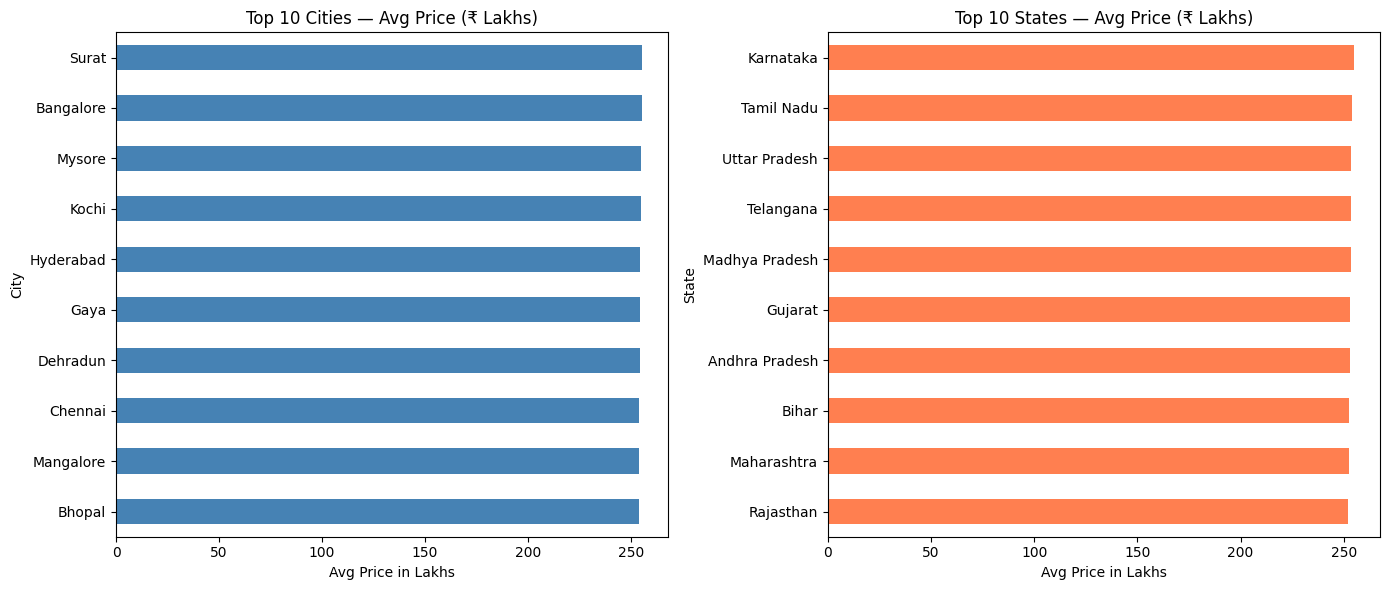

In [ ]:
import matplotlib.pyplot as plt

cap_price = df_eda['Price_in_Lakhs'].quantile(0.99)
df_viz    = df_eda[df_eda['Price_in_Lakhs'] <= cap_price].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_cities = (df_viz.groupby('City')['Price_in_Lakhs']
                    .mean()
                    .sort_values(ascending=False)
                    .head(10))

top_states = (df_viz.groupby('State')['Price_in_Lakhs']
                    .mean()
                    .sort_values(ascending=False)
                    .head(10))

top_cities.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Top 10 Cities — Avg Price (₹ Lakhs)')
axes[0].set_xlabel('Avg Price in Lakhs')

top_states.plot(kind='barh', ax=axes[1], color='coral')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 States — Avg Price (₹ Lakhs)')
axes[1].set_xlabel('Avg Price in Lakhs')

plt.tight_layout()
plt.show()

#### **Outlier Check**

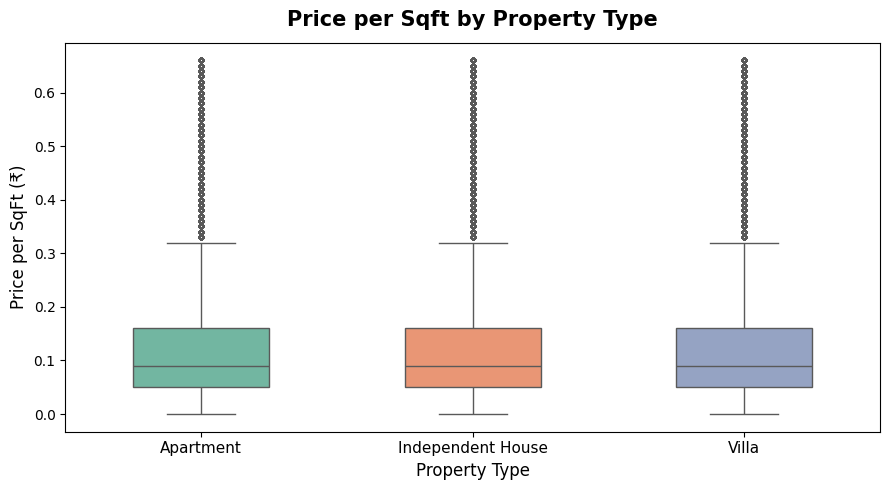

In [ ]:
import seaborn as sns

cap_ppsf = df['Price_per_SqFt'].quantile(0.99)
df_viz2  = df[df['Price_per_SqFt'] <= cap_ppsf].copy()

# decode the labels properly before plotting
df_viz2['Property_Type_Label'] = label_encoders['Property_Type'].inverse_transform(
    df_viz2['Property_Type']
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df_viz2,
    x='Property_Type_Label',
    y='Price_per_SqFt',
    ax=ax,
    hue='Property_Type_Label',
    palette='Set2',
    width=0.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none'),
    legend=False
)

ax.set_title('Price per Sqft by Property Type', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Property Type', fontsize=12)
ax.set_ylabel('Price per SqFt (₹)', fontsize=12)
ax.tick_params(axis='x', labelsize=11)

plt.tight_layout()
plt.show()

#### **Feature Correlation Heatmap**

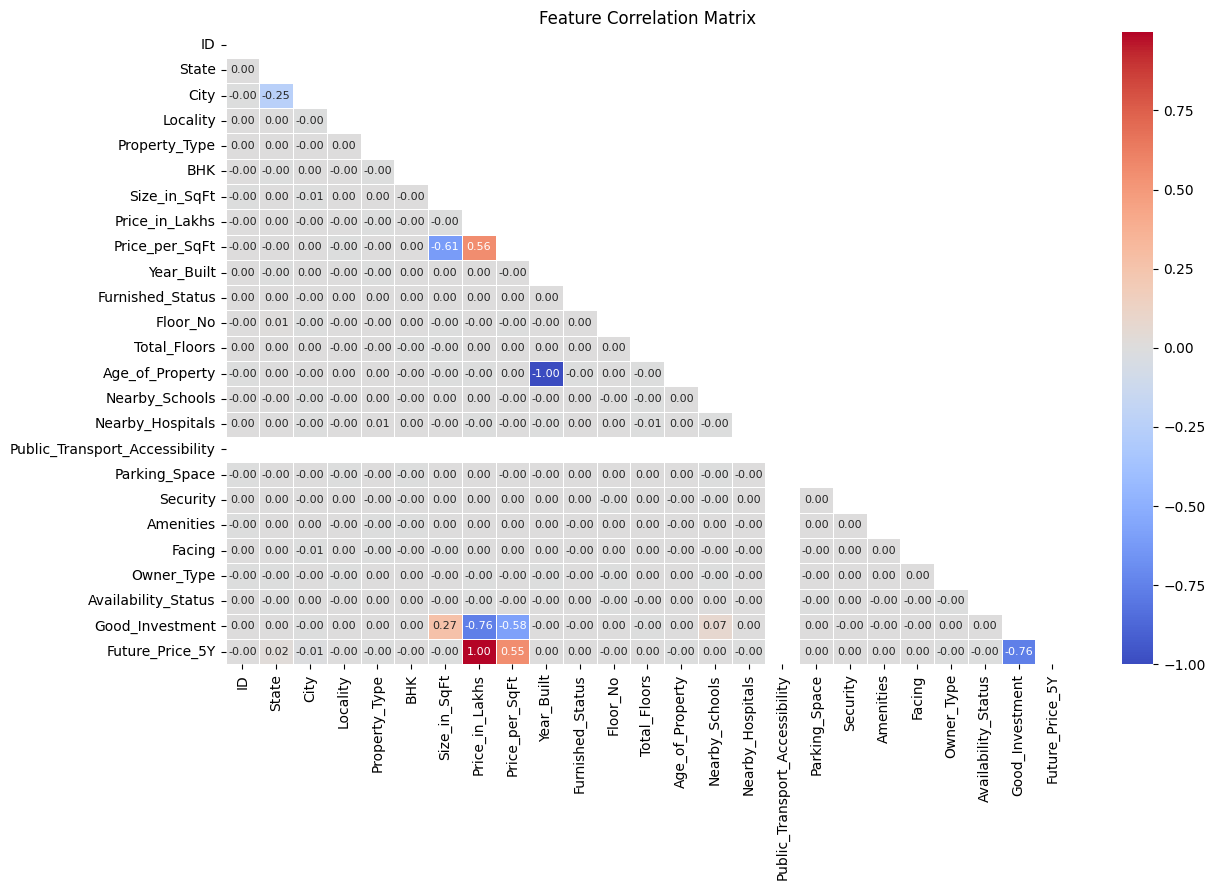


Top correlations with Price_in_Lakhs:
Future_Price_5Y                   0.996450
Price_per_SqFt                    0.555625
Security                          0.003808
Year_Built                        0.002714
Amenities                         0.002591
State                             0.002445
Furnished_Status                  0.001544
Total_Floors                      0.001283
Parking_Space                     0.001118
Facing                            0.000784
Nearby_Schools                    0.000155
Locality                         -0.000341
City                             -0.000509
BHK                              -0.000980
ID                               -0.001636
Floor_No                         -0.001719
Owner_Type                       -0.001906
Property_Type                    -0.002476
Size_in_SqFt                     -0.002529
Age_of_Property                  -0.002714
Nearby_Hospitals                 -0.002769
Availability_Status              -0.002807
Good_Investment

In [ ]:
fig, ax = plt.subplots(figsize=(13, 9))

num_cols = df.select_dtypes(include=np.number).drop(
    columns=['City_Label', 'State_Label'], errors='ignore'
).columns

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nTop correlations with Price_in_Lakhs:")
print(corr['Price_in_Lakhs'].drop('Price_in_Lakhs').sort_values(ascending=False).to_string())

#### **Investment Analysis**

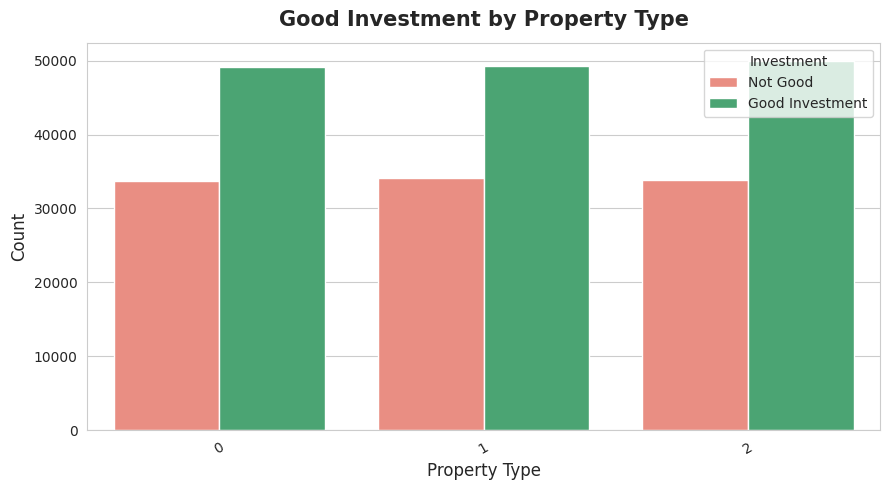

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df_geo = pd.read_csv('/content/drive/MyDrive/engineered_data.csv')

fig, ax = plt.subplots(figsize=(9, 5))

sns.countplot(
    data=df_geo,
    x='Property_Type',
    hue='Good_Investment',
    palette={0: 'salmon', 1: 'mediumseagreen'},
    ax=ax,
    edgecolor='white'
)

ax.set_title('Good Investment by Property Type', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Property Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=30)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Not Good', 'Good Investment'], title='Investment', fontsize=10)

plt.tight_layout()
plt.show()

#### **Price Distribution**

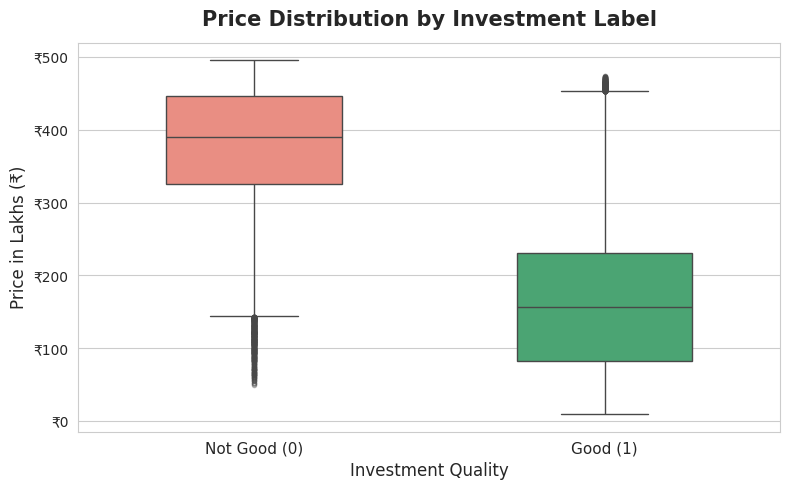

In [ ]:
cap_price = df_geo['Price_in_Lakhs'].quantile(0.99)
df_capped = df_geo[df_geo['Price_in_Lakhs'] <= cap_price].copy()

# Ensure 'Good_Investment' is treated as categorical strings for plotting
# Convert 'Good_Investment' to string type first, then to categorical
df_capped['Good_Investment'] = df_capped['Good_Investment'].astype(str).astype('category')

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df_capped,
    x='Good_Investment',
    y='Price_in_Lakhs',
    hue='Good_Investment', # Added hue argument
    palette={'0': 'salmon', '1': 'mediumseagreen'}, # Use string keys to match string 'Good_Investment'
    ax=ax,
    width=0.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none'),
    legend=False # Added legend=False to suppress the legend generated by hue
)

ax.set_title('Price Distribution by Investment Label', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Investment Quality', fontsize=12)
ax.set_ylabel('Price in Lakhs (₹)', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Good (0)', 'Good (1)'], fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.tight_layout()
plt.show()

### **Amenities & Infrastructure Impact**

Transport value counts: {0: 250000}


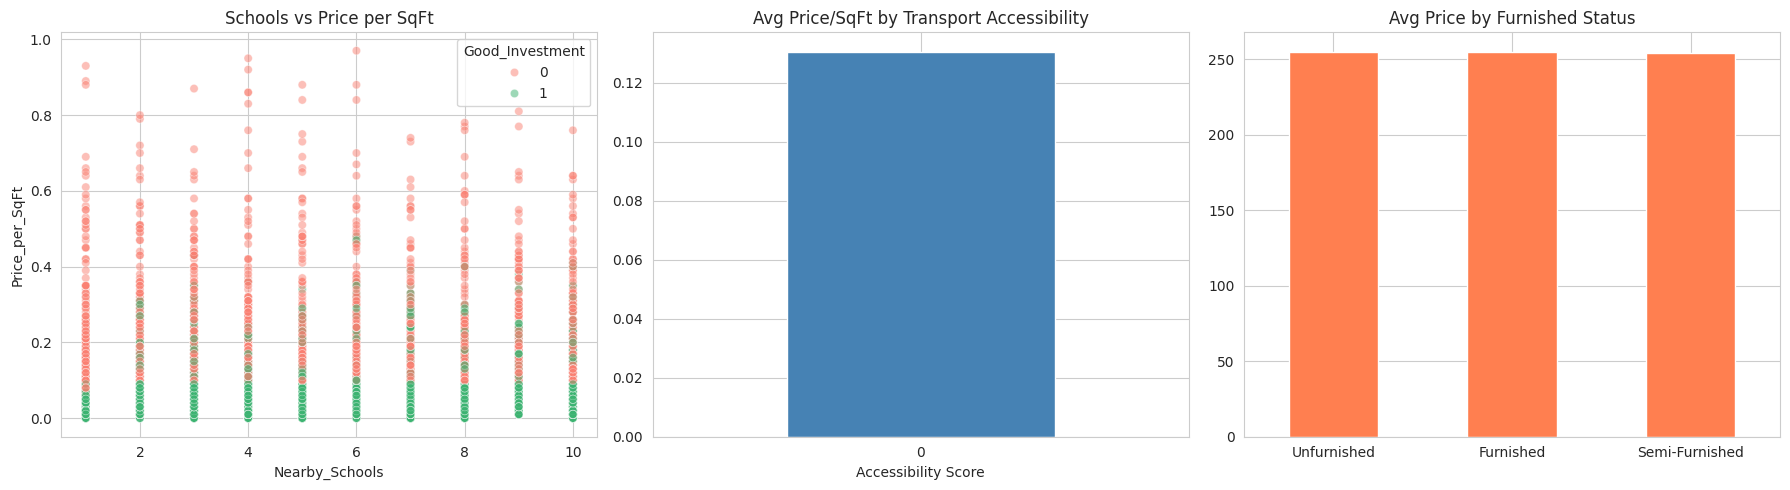

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sample = df_eda.sample(min(5000, len(df_eda)), random_state=42)
sns.scatterplot(data=sample, x='Nearby_Schools', y='Price_per_SqFt',
                hue='Good_Investment', palette={0: 'salmon', 1: 'mediumseagreen'},
                alpha=0.5, ax=axes[0])
axes[0].set_title('Schools vs Price per SqFt')

print("Transport value counts:", df_eda['Public_Transport_Accessibility'].value_counts().sort_index().to_dict())
transport_avg = (df_eda.groupby('Public_Transport_Accessibility')['Price_per_SqFt']
                       .mean()
                       .sort_index())
transport_avg.plot(kind='bar', ax=axes[1], color='steelblue', rot=0)
axes[1].set_title('Avg Price/SqFt by Transport Accessibility')
axes[1].set_xlabel('Accessibility Score')

furnished_avg = (df_eda.groupby('Furnished_Status')['Price_in_Lakhs']
                       .mean()
                       .sort_values(ascending=False))
furnished_avg.plot(kind='bar', ax=axes[2], color='coral', rot=0)
axes[2].set_title('Avg Price by Furnished Status')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

### **Future Price Analysis**

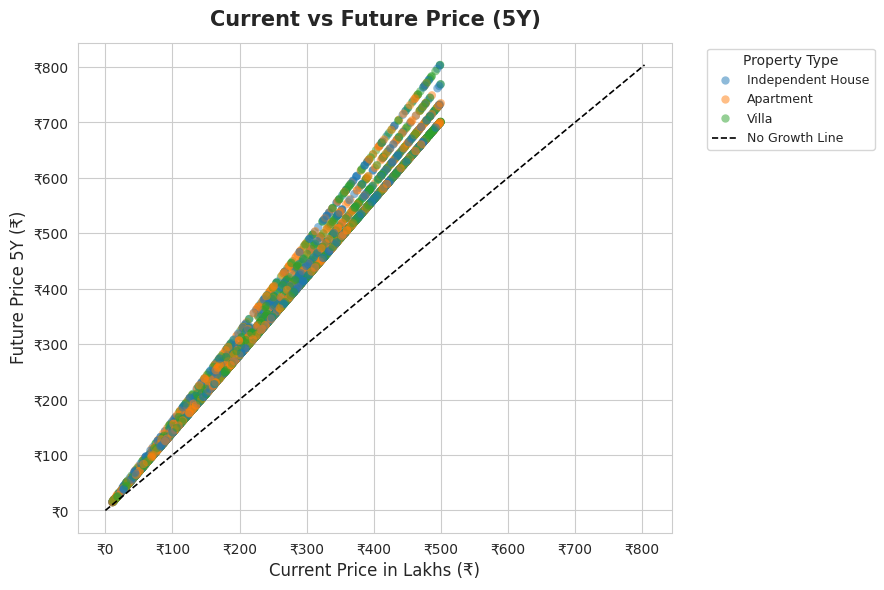

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df_geo = pd.read_csv('/content/drive/MyDrive/engineered_data.csv')

sample = df_geo.sample(min(5000, len(df_geo)), random_state=42)

sample['PT_Label'] = label_encoders['Property_Type'].inverse_transform(sample['Property_Type'])

fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=sample,
    x='Price_in_Lakhs',
    y='Future_Price_5Y',
    hue='PT_Label',
    alpha=0.5,
    ax=ax,
    edgecolor='none'
)

max_val = sample[['Price_in_Lakhs', 'Future_Price_5Y']].max().max()
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1.2, label='No Growth Line')

ax.set_title('Current vs Future Price (5Y)', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Current Price in Lakhs (₹)', fontsize=12)
ax.set_ylabel('Future Price 5Y (₹)', fontsize=12)
ax.legend(title='Property Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.tight_layout()
plt.show()

### **Model Training**

---



1.   Feature Selection & Train-Test Split

1.   Feature Scaling
2.   Classification Model Training


2.   Regression Model Training





#### **Feature Selection & Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

df_model = pd.read_csv('/content/drive/MyDrive/engineered_data.csv')

drop_cols = [c for c in ['ID', 'Year_Built', 'Future_Price_5Y', 'Good_Investment',
                          'City_Label', 'State_Label', 'PT_Label', 'FS_Label']
             if c in df_model.columns]

X       = df_model.drop(columns=drop_cols)
y_clf   = df_model['Good_Investment']
y_reg   = df_model['Future_Price_5Y']

X_train, X_test, y_clf_train, y_clf_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42, stratify=y_clf
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_clf_train:", y_clf_train.shape, "| class balance:", y_clf_train.mean().round(3))
print("y_reg_train:", y_reg_train.shape, "| mean value:", y_reg_train.mean().round(2))

X_train: (200000, 21)
X_test:  (50000, 21)
y_clf_train: (200000,) | class balance: 0.593
y_reg_train: (200000,) | mean value: 364.91


### **Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib

# Identify columns that need encoding and apply LabelEncoder
string_cols_to_encode = ['Amenities', 'Parking_Space']

for col in string_cols_to_encode:
    if col in X_train.columns and X_train[col].dtype == 'object':
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
        # Store these new encoders in the global label_encoders dict
        label_encoders[col] = le

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, '/content/drive/MyDrive/scaler.pkl')

key_features = ['Price_in_Lakhs', 'Size_in_SqFt', 'Age_of_Property']
key_idx      = [X_train.columns.get_loc(c) for c in key_features if c in X_train.columns]

print(f"{'Feature':<25} {'Mean (before)':>14} {'Std (before)':>13} {'Mean (after)':>13} {'Std (after)':>11}")
print("-" * 78)
for col, idx in zip(key_features, key_idx):
    print(f"{col:<25} {X_train[col].mean():>14.2f} {X_train[col].std():>13.2f} "
          f"{X_train_scaled[:, idx].mean():>13.6f} {X_train_scaled[:, idx].std():>11.6f}")

print("\nScaler saved.")

Feature                    Mean (before)  Std (before)  Mean (after) Std (after)
------------------------------------------------------------------------------
Price_in_Lakhs                    254.50        141.39      0.000000    1.000000
Size_in_SqFt                     2750.71       1300.57     -0.000000    1.000000
Age_of_Property                    18.47          9.82     -0.000000    1.000000

Scaler saved.


### **Classification Model Training**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def train_classifiers(X_train, y_train):
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    xgb = XGBClassifier(n_estimators=100, random_state=42,
                         eval_metric='logloss', verbosity=0)
    xgb.fit(X_train, y_train)

    print(f"Random Forest  — Train Accuracy: {rf.score(X_train, y_train):.4f}")
    print(f"XGBoost        — Train Accuracy: {xgb.score(X_train, y_train):.4f}")

    return rf, xgb

rf_clf, xgb_clf = train_classifiers(X_train_scaled, y_clf_train)

joblib.dump(rf_clf,  '/content/drive/MyDrive/rf_clf.pkl')
joblib.dump(xgb_clf, '/content/drive/MyDrive/xgb_clf.pkl')
print("\nClassification models saved.")

Random Forest  — Train Accuracy: 1.0000
XGBoost        — Train Accuracy: 1.0000

Classification models saved.


### **Regression Model Training**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

def train_regressors(X_train, y_train):
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xgb.fit(X_train, y_train)

    print(f"Random Forest  — Train R²: {rf.score(X_train, y_train):.4f}")
    print(f"XGBoost        — Train R²: {xgb.score(X_train, y_train):.4f}")

    return rf, xgb

rf_reg, xgb_reg = train_regressors(X_train_scaled, y_reg_train)

joblib.dump(rf_reg,  '/content/drive/MyDrive/rf_reg.pkl')
joblib.dump(xgb_reg, '/content/drive/MyDrive/xgb_reg.pkl')
print("\nRegression models saved.")

Random Forest  — Train R²: 1.0000
XGBoost        — Train R²: 1.0000

Regression models saved.


### **Model Evaluation**

---



1.   Classification Evaluation

1.   ROC-AUC Curve

1.   Regression Evaluation
2.   Feature Importance



#### **Classification Metrics + Confusion Matrices**


  Random Forest Classifier
  Accuracy  : 0.9975
  Precision : 0.9984
  Recall    : 0.9974
  F1 Score  : 0.9979

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20328
           1       1.00      1.00      1.00     29672

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000


  XGBoost Classifier
  Accuracy  : 0.9995
  Precision : 0.9996
  Recall    : 0.9995
  F1 Score  : 0.9995

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20328
           1       1.00      1.00      1.00     29672

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000



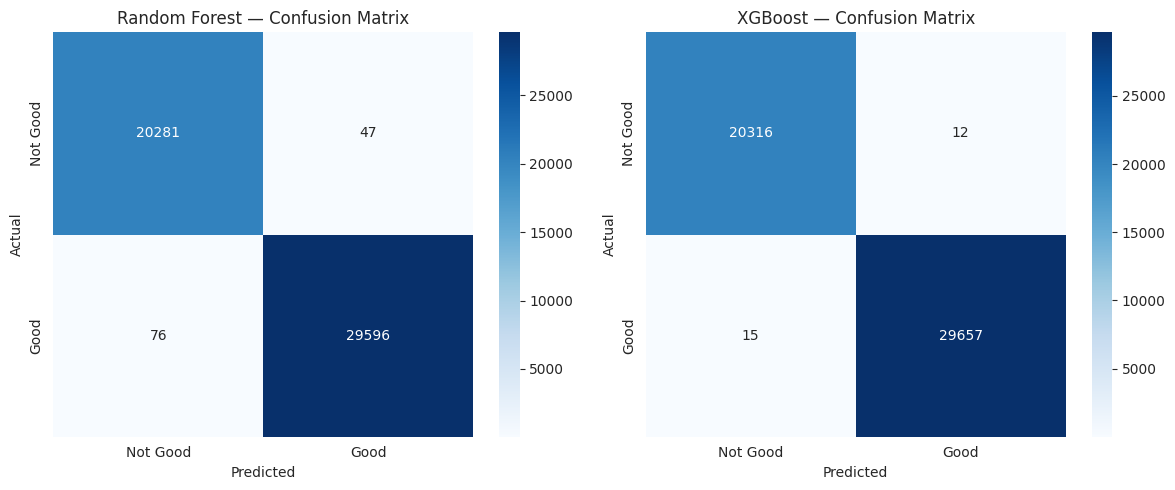

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              roc_curve, auc)
import joblib

rf_clf  = joblib.load('/content/drive/MyDrive/rf_clf.pkl')
xgb_clf = joblib.load('/content/drive/MyDrive/xgb_clf.pkl')

def evaluate_classifier(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy_score(y_test, preds):.4f}")
    print(f"  Precision : {precision_score(y_test, preds):.4f}")
    print(f"  Recall    : {recall_score(y_test, preds):.4f}")
    print(f"  F1 Score  : {f1_score(y_test, preds):.4f}")
    print(f"\n{classification_report(y_test, preds)}")
    return preds

rf_preds  = evaluate_classifier(rf_clf,  X_test_scaled, y_clf_test, "Random Forest Classifier")
xgb_preds = evaluate_classifier(xgb_clf, X_test_scaled, y_clf_test, "XGBoost Classifier")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in zip(axes,
                             [rf_preds, xgb_preds],
                             ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_clf_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Good', 'Good'],
                yticklabels=['Not Good', 'Good'])
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### **ROC-AUC Curve**

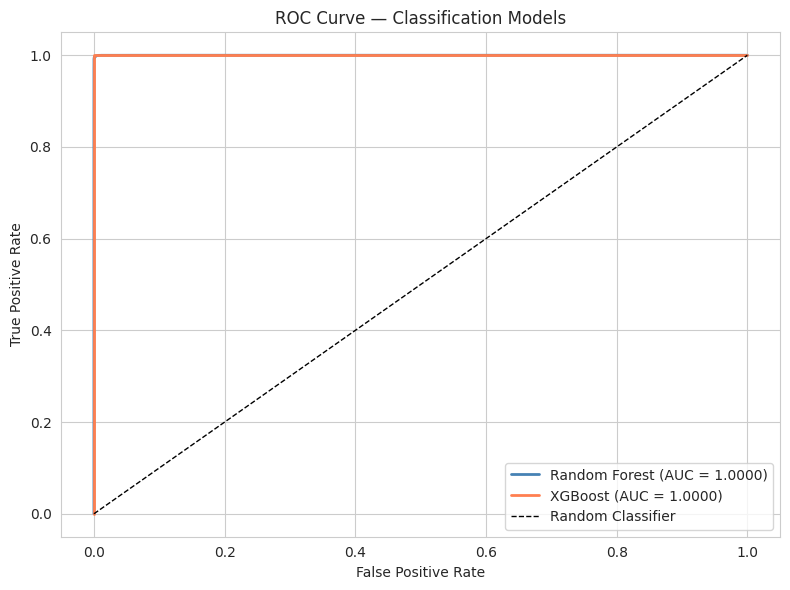

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for model, name, color in zip([rf_clf, xgb_clf],
                               ['Random Forest', 'XGBoost'],
                               ['steelblue', 'coral']):
    probs    = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_clf_test, probs)
    roc_auc  = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Classification Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### **Regression Metrics + Actual vs Predicted**


  Random Forest Regressor
  RMSE : 0.3776
  MAE  : 0.1277
  R²   : 1.0000

  XGBoost Regressor
  RMSE : 1.3464
  MAE  : 1.0295
  R²   : 1.0000


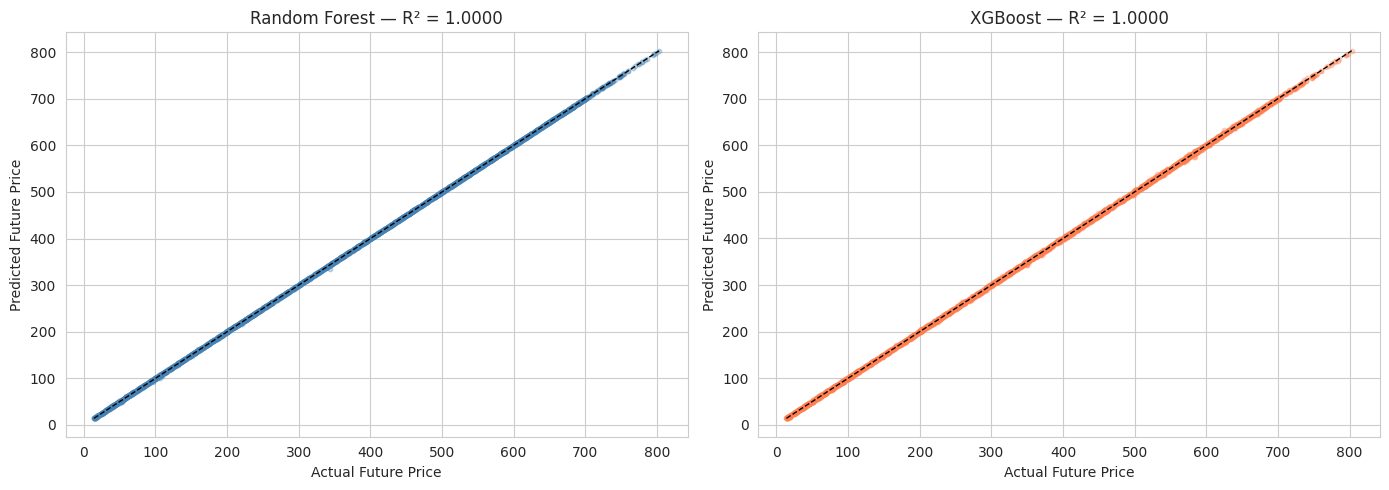

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf_reg  = joblib.load('/content/drive/MyDrive/rf_reg.pkl')
xgb_reg = joblib.load('/content/drive/MyDrive/xgb_reg.pkl')

def evaluate_regressor(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mae   = mean_absolute_error(y_test, preds)
    r2    = r2_score(y_test, preds)
    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return preds, r2

rf_reg_preds,  rf_r2  = evaluate_regressor(rf_reg,  X_test_scaled, y_reg_test, "Random Forest Regressor")
xgb_reg_preds, xgb_r2 = evaluate_regressor(xgb_reg, X_test_scaled, y_reg_test, "XGBoost Regressor")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample_idx = np.random.choice(len(y_reg_test), size=3000, replace=False)
y_sample   = np.array(y_reg_test)[sample_idx]

for ax, preds, name, r2, color in zip(
    axes,
    [rf_reg_preds, xgb_reg_preds],
    ['Random Forest', 'XGBoost'],
    [rf_r2, xgb_r2],
    ['steelblue', 'coral']
):
    ax.scatter(y_sample, preds[sample_idx], alpha=0.3, s=10, color=color)
    lims = [min(y_sample.min(), preds[sample_idx].min()),
            max(y_sample.max(), preds[sample_idx].max())]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_title(f'{name} — R² = {r2:.4f}')
    ax.set_xlabel('Actual Future Price')
    ax.set_ylabel('Predicted Future Price')

plt.tight_layout()
plt.show()

### **Feature Importance (Classifier + Regressor)**

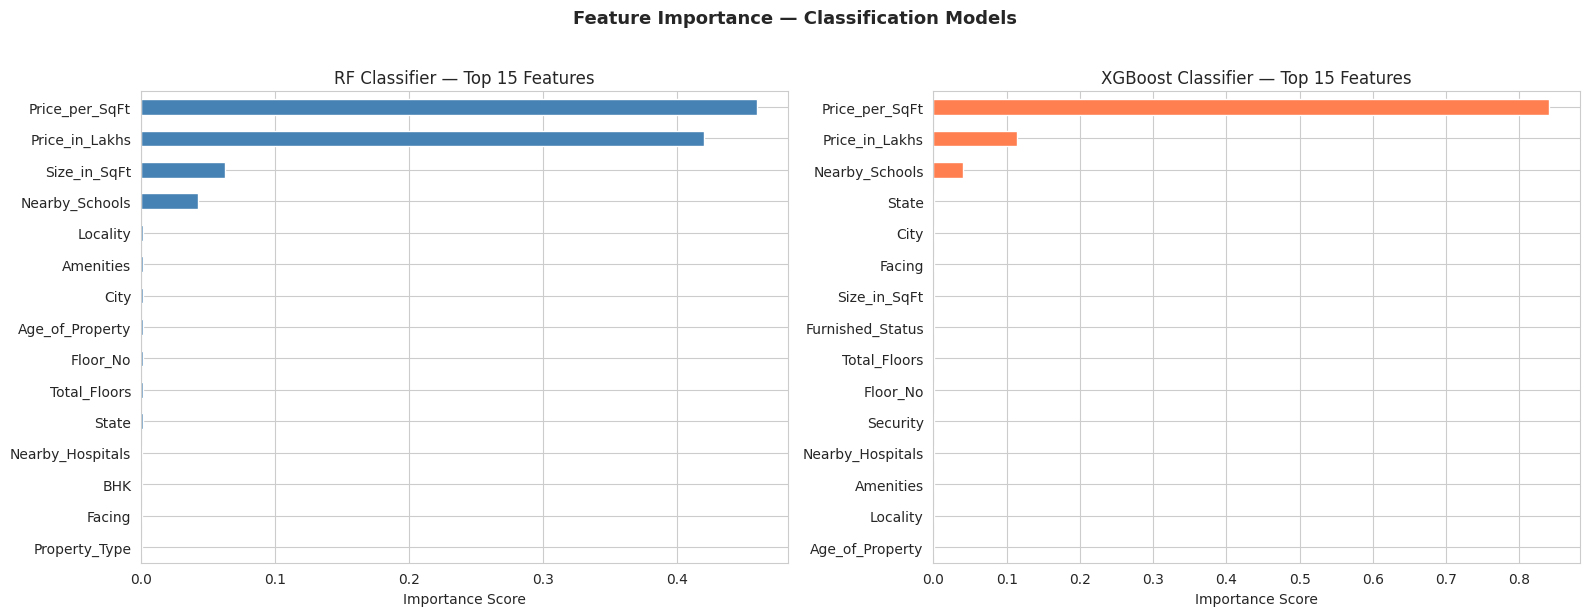

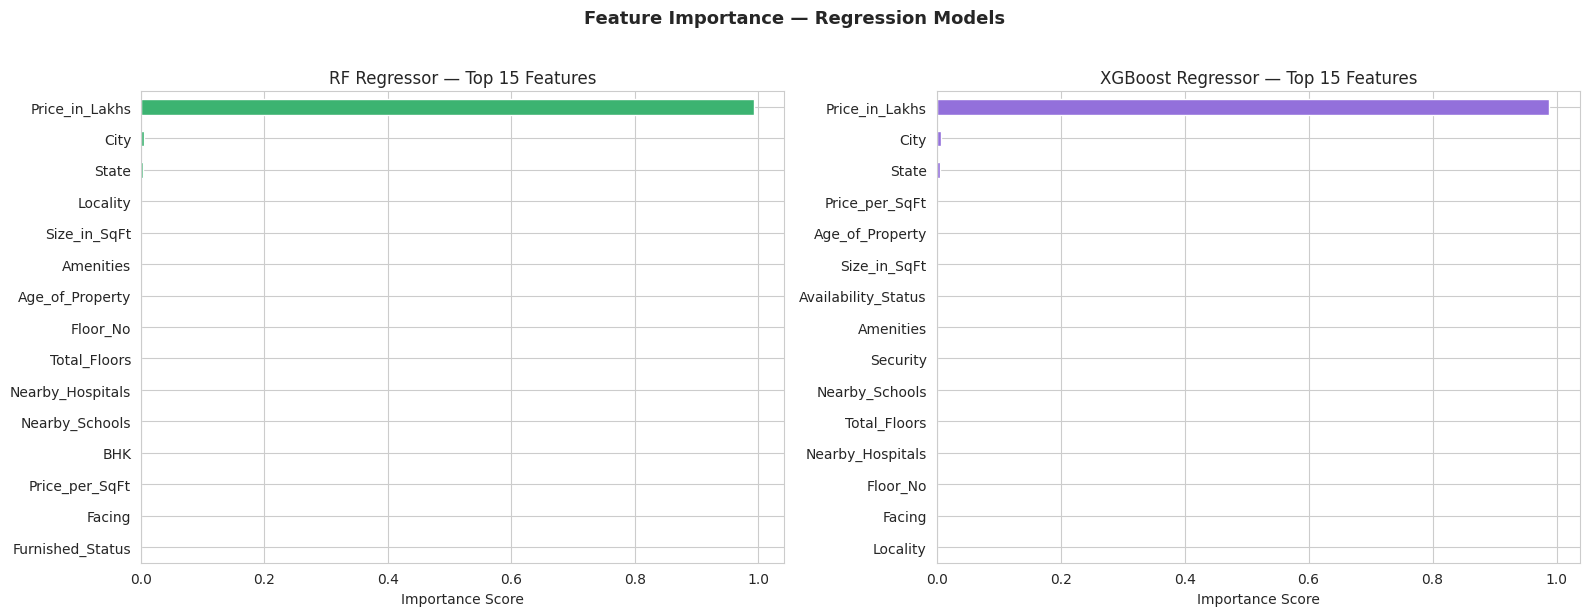

In [ ]:
feature_names = X_train.columns.tolist()

def plot_feature_importance(models, names, colors, title, top_n=15):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, model, name, color in zip(axes, models, names, colors):
        importance = pd.Series(model.feature_importances_, index=feature_names)
        importance = importance.sort_values(ascending=False).head(top_n)
        importance.sort_values().plot(kind='barh', ax=ax, color=color)
        ax.set_title(f'{name} — Top {top_n} Features')
        ax.set_xlabel('Importance Score')
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_feature_importance(
    models  = [rf_clf, xgb_clf],
    names   = ['RF Classifier', 'XGBoost Classifier'],
    colors  = ['steelblue', 'coral'],
    title   = 'Feature Importance — Classification Models'
)

plot_feature_importance(
    models  = [rf_reg, xgb_reg],
    names   = ['RF Regressor', 'XGBoost Regressor'],
    colors  = ['mediumseagreen', 'mediumpurple'],
    title   = 'Feature Importance — Regression Models'
)

### **MLflow Integration**

---



1.   MLflow Setup

1.   Log Classification Models

1.   Log Regression Models

1.   Register Best Models
2.   Load & Verify Registered Models






#### **MLflow Setup**

In [ ]:
!pip install mlflow -q

import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("real_estate_investment_advisor")

client = MlflowClient()
exp    = client.get_experiment_by_name("real_estate_investment_advisor")
print(f"Experiment set : real_estate_investment_advisor")
print(f"Experiment ID  : {exp.experiment_id}")
print(f"Tracking URI   : {mlflow.get_tracking_uri()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.5/857.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/20 13:16:15 INFO mlflow.tracking.fluent: Experiment with name 'real_estate_investment_advisor' does not exist. Creating a new experiment.


Experiment set : real_estate_investment_advisor
Experiment ID  : 332731887297075115
Tracking URI   : ./mlruns


### **Log Classification Models**

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score)

def log_classification_run(model, X_test, y_test, model_name):
    preds  = model.predict(X_test)
    probs  = model.predict_proba(X_test)[:, 1]

    params  = {
        "n_estimators": model.n_estimators,
        "max_depth"   : str(model.max_depth),
        "random_state": model.random_state
    }
    metrics = {
        "accuracy" : accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall"   : recall_score(y_test, preds),
        "f1"       : f1_score(y_test, preds),
        "roc_auc"  : roc_auc_score(y_test, probs)
    }

    with mlflow.start_run(run_name=model_name) as run:
        mlflow.set_tag("model_type", "classification")
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)

        if "XGB" in type(model).__name__:
            mlflow.xgboost.log_model(model, artifact_path="model")
        else:
            mlflow.sklearn.log_model(model, artifact_path="model")

        run_id = run.info.run_id
        print(f"{model_name:<35} Run ID: {run_id}")
        print(f"  F1: {metrics['f1']:.4f} | AUC: {metrics['roc_auc']:.4f}")

    return run_id, metrics['f1']

print("Logging classification models...\n")
rf_clf_run_id,  rf_clf_f1  = log_classification_run(rf_clf,  X_test_scaled, y_clf_test, "Random Forest Classifier")
xgb_clf_run_id, xgb_clf_f1 = log_classification_run(xgb_clf, X_test_scaled, y_clf_test, "XGBoost Classifier")

Logging classification models...



2026/04/20 13:16:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 13:16:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Classifier            Run ID: 17d84cc555d341bdb71e65c051ef3713
  F1: 0.9979 | AUC: 1.0000


2026/04/20 13:16:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost Classifier                  Run ID: e2ccd3f709994efcbe8317909ab6fa3b
  F1: 0.9995 | AUC: 1.0000


### **Log Regression Models**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def log_regression_run(model, X_test, y_test, model_name):
    preds = model.predict(X_test)

    params  = {
        "n_estimators": model.n_estimators,
        "max_depth"   : str(model.max_depth),
        "random_state": model.random_state
    }
    metrics = {
        "rmse": np.sqrt(mean_squared_error(y_test, preds)),
        "mae" : mean_absolute_error(y_test, preds),
        "r2"  : r2_score(y_test, preds)
    }

    with mlflow.start_run(run_name=model_name) as run:
        mlflow.set_tag("model_type", "regression")
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)

        if "XGB" in type(model).__name__:
            mlflow.xgboost.log_model(model, artifact_path="model")
        else:
            mlflow.sklearn.log_model(model, artifact_path="model")

        run_id = run.info.run_id
        print(f"{model_name:<35} Run ID: {run_id}")
        print(f"  RMSE: {metrics['rmse']:.4f} | R²: {metrics['r2']:.4f}")

    return run_id, metrics['rmse']

print("Logging regression models...\n")
rf_reg_run_id,  rf_reg_rmse  = log_regression_run(rf_reg,  X_test_scaled, y_reg_test, "Random Forest Regressor")
xgb_reg_run_id, xgb_reg_rmse = log_regression_run(xgb_reg, X_test_scaled, y_reg_test, "XGBoost Regressor")

Logging regression models...



2026/04/20 13:16:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 13:16:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/20 13:17:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random Forest Regressor             Run ID: ef998556fe5349cba8518630fba8c8b6
  RMSE: 0.3776 | R²: 1.0000
XGBoost Regressor                   Run ID: 5334e21d63984f91975339668071136a
  RMSE: 1.3464 | R²: 1.0000


### **Register Best Models**

In [ ]:
def register_best_model(run_id, model_name, artifact_path="model"):
    model_uri = f"runs:/{run_id}/{artifact_path}"
    result    = mlflow.register_model(model_uri=model_uri, name=model_name)
    print(f"Registered : {result.name}  |  Version: {result.version}  |  Run: {run_id[:8]}...")
    return result

print("Registering best models...\n")

best_clf_run_id = rf_clf_run_id  if rf_clf_f1   >= xgb_clf_f1   else xgb_clf_run_id
best_reg_run_id = rf_reg_run_id  if rf_reg_rmse <= xgb_reg_rmse else xgb_reg_run_id

best_clf_name = "Random Forest Classifier" if rf_clf_f1   >= xgb_clf_f1   else "XGBoost Classifier"
best_reg_name = "Random Forest Regressor"  if rf_reg_rmse <= xgb_reg_rmse else "XGBoost Regressor"

print(f"Best Classifier : {best_clf_name} (F1: {max(rf_clf_f1, xgb_clf_f1):.4f})")
print(f"Best Regressor  : {best_reg_name} (RMSE: {min(rf_reg_rmse, xgb_reg_rmse):.4f})\n")

clf_registered = register_best_model(best_clf_run_id, "best_classifier")
reg_registered = register_best_model(best_reg_run_id, "best_regressor")

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_model_registry/utils.py:220: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri)
Successfully registered model 'best_classifier'.
2026/04/20 13:17:51 WARNING mlflow.tracking._model_registry.fluent: Run with id e2ccd3f709994efcbe8317909ab6fa3b has no artifacts at artifact path 'model', registering model based on models:/m-e5cc6de6cb364e29b8700d951add1e49 instead
Created version '1' of model 'best_classifier'.
Successfully registered model 'best_regressor'.
2026/04/20 13:17:51 WARNING mlflow.tracking._model_registry.fluent: Run with id ef998556fe5349cba8518630fba8c8b6 has no artifacts at artifact path 'model', registering model base

Registering best models...

Best Classifier : XGBoost Classifier (F1: 0.9995)
Best Regressor  : Random Forest Regressor (RMSE: 0.3776)

Registered : best_classifier  |  Version: 1  |  Run: e2ccd3f7...
Registered : best_regressor  |  Version: 1  |  Run: ef998556...


Created version '1' of model 'best_regressor'.


### **Load & Verify Registered Models**

In [ ]:
def load_and_verify(registry_name, X_sample, task="classification"):
    model_uri    = f"models:/{registry_name}/latest"
    loaded_model = mlflow.pyfunc.load_model(model_uri)
    preds        = loaded_model.predict(pd.DataFrame(X_sample, columns=X_train.columns))

    print(f"\nLoaded  : {registry_name}")
    print(f"URI     : {model_uri}")
    print(f"Sample predictions ({task}):")
    print(preds[:5].tolist())
    return loaded_model

X_sample = X_test_scaled[:5]

loaded_clf = load_and_verify("best_classifier", X_sample, task="classification")
loaded_reg = load_and_verify("best_regressor",  X_sample, task="regression")


Loaded  : best_classifier
URI     : models:/best_classifier/latest
Sample predictions (classification):
[0, 0, 1, 1, 1]

Loaded  : best_regressor
URI     : models:/best_regressor/latest
Sample predictions (regression):
[656.3873, 616.0680999999998, 385.7775000000001, 328.8081000000002, 217.50080000000005]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


### **Streamlit App**
*@ChatGPT help*


In [ ]:
%%writefile app.py
# To run locally: streamlit run app.py
# To run in Colab:
# !pip install streamlit pyngrok -q
# from pyngrok import ngrok
# !streamlit run app.py &
# ngrok.set_auth_token("YOUR_TOKEN")
# public_url = ngrok.connect(8501)
# print(public_url)

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

st.set_page_config(
    page_title="Real Estate Investment Advisor",
    page_icon="🏠",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ── Custom CSS ────────────────────────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Syne:wght@400;600;700;800&family=DM+Sans:wght@300;400;500&display=swap');

html, body, [class*="css"] {
    font-family: 'DM Sans', sans-serif;
}

/* Background */
.stApp {
    background: #0d0f14;
    color: #e8e6e0;
}

/* Sidebar */
[data-testid="stSidebar"] {
    background: #13161d !important;
    border-right: 1px solid #1f2330;
}
[data-testid="stSidebar"] * { color: #c9c7c0 !important; }

/* Header strip */
.app-header {
    background: linear-gradient(135deg, #1a1f2e 0%, #0d1117 100%);
    border: 1px solid #1f2a3c;
    border-radius: 12px;
    padding: 28px 36px;
    margin-bottom: 28px;
    display: flex;
    align-items: center;
    gap: 20px;
    position: relative;
    overflow: hidden;
}
.app-header::before {
    content: '';
    position: absolute;
    top: -40px; right: -40px;
    width: 180px; height: 180px;
    background: radial-gradient(circle, rgba(99,179,237,0.08) 0%, transparent 70%);
    border-radius: 50%;
}
.app-header h1 {
    font-family: 'Syne', sans-serif;
    font-size: 2rem;
    font-weight: 800;
    color: #f0ede6;
    margin: 0;
    letter-spacing: -0.5px;
}
.app-header p {
    color: #6b7280;
    margin: 4px 0 0 0;
    font-size: 0.9rem;
    font-weight: 300;
}
.header-icon {
    font-size: 2.8rem;
    line-height: 1;
}

/* Metric cards */
.metric-grid {
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 16px;
    margin: 20px 0;
}
.metric-card {
    background: #13161d;
    border: 1px solid #1f2330;
    border-radius: 10px;
    padding: 20px 24px;
    position: relative;
    overflow: hidden;
    transition: border-color 0.2s;
}
.metric-card:hover { border-color: #2d3748; }
.metric-card .label {
    font-size: 0.72rem;
    font-weight: 500;
    text-transform: uppercase;
    letter-spacing: 1.2px;
    color: #4a5568;
    margin-bottom: 8px;
}
.metric-card .value {
    font-family: 'Syne', sans-serif;
    font-size: 1.6rem;
    font-weight: 700;
    color: #f0ede6;
    line-height: 1.1;
}
.metric-card .sub {
    font-size: 0.78rem;
    color: #4a5568;
    margin-top: 4px;
}
.metric-card.good  { border-left: 3px solid #48bb78; }
.metric-card.bad   { border-left: 3px solid #f56565; }
.metric-card.info  { border-left: 3px solid #63b3ed; }
.metric-card.gold  { border-left: 3px solid #d69e2e; }

/* Result banner */
.result-good {
    background: linear-gradient(135deg, #1a2e22, #162318);
    border: 1px solid #2f6b43;
    border-radius: 10px;
    padding: 18px 24px;
    color: #68d391;
    font-family: 'Syne', sans-serif;
    font-weight: 700;
    font-size: 1.05rem;
    display: flex; align-items: center; gap: 10px;
}
.result-bad {
    background: linear-gradient(135deg, #2d1b1b, #231414);
    border: 1px solid #6b2f2f;
    border-radius: 10px;
    padding: 18px 24px;
    color: #fc8181;
    font-family: 'Syne', sans-serif;
    font-weight: 700;
    font-size: 1.05rem;
    display: flex; align-items: center; gap: 10px;
}

/* Section titles */
.section-title {
    font-family: 'Syne', sans-serif;
    font-size: 1.1rem;
    font-weight: 700;
    color: #c9c7c0;
    letter-spacing: -0.2px;
    margin: 24px 0 14px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #1f2330;
}

/* Sidebar predict button */
.stButton > button {
    width: 100%;
    background: linear-gradient(135deg, #2b4c7e, #1a3356) !important;
    color: #e8f4fd !important;
    border: 1px solid #2d5a9e !important;
    border-radius: 8px !important;
    padding: 12px !important;
    font-family: 'Syne', sans-serif !important;
    font-weight: 700 !important;
    font-size: 0.9rem !important;
    letter-spacing: 0.5px !important;
    transition: all 0.2s !important;
}
.stButton > button:hover {
    background: linear-gradient(135deg, #3459a0, #1f3d6b) !important;
    border-color: #4a7bc8 !important;
}

/* Tabs */
.stTabs [data-baseweb="tab-list"] {
    background: #13161d;
    border-radius: 8px;
    padding: 4px;
    gap: 4px;
    border: 1px solid #1f2330;
}
.stTabs [data-baseweb="tab"] {
    background: transparent !important;
    color: #4a5568 !important;
    border-radius: 6px !important;
    font-family: 'DM Sans', sans-serif !important;
    font-size: 0.85rem !important;
    padding: 8px 16px !important;
}
.stTabs [aria-selected="true"] {
    background: #1f2a3c !important;
    color: #90cdf4 !important;
}

/* Plotly chart backgrounds */
.js-plotly-plot { border-radius: 10px; }

/* Divider */
hr { border-color: #1f2330 !important; }

/* Footer */
.footer {
    text-align: center;
    color: #2d3748;
    font-size: 0.78rem;
    padding: 20px 0 8px 0;
    letter-spacing: 0.3px;
}

/* Sidebar section label */
.sidebar-section {
    font-family: 'Syne', sans-serif;
    font-size: 0.7rem;
    font-weight: 700;
    text-transform: uppercase;
    letter-spacing: 1.5px;
    color: #2d3748 !important;
    margin: 20px 0 8px 0;
}

[data-testid="stSidebar"] .sidebar-section { color: #3d4a5c !important; }
</style>
""", unsafe_allow_html=True)

PLOTLY_THEME = dict(
    paper_bgcolor="#0d0f14",
    plot_bgcolor="#13161d",
    font_color="#8892a0",
    font_family="DM Sans",
    colorway=["#63b3ed", "#68d391", "#f6ad55", "#fc8181", "#b794f4", "#76e4f7"],
    xaxis=dict(gridcolor="#1a1f2e", linecolor="#1f2330", zerolinecolor="#1a1f2e"),
    yaxis=dict(gridcolor="#1a1f2e", linecolor="#1f2330", zerolinecolor="#1a1f2e"),
)

# ── Data & Model Loading ──────────────────────────────────────────────────────
@st.cache_resource(show_spinner=False)
def load_models():
    base = "/content/drive/MyDrive/"
    scaler  = joblib.load(base + "scaler.pkl")
    clf     = joblib.load(base + "rf_clf.pkl")
    reg     = joblib.load(base + "rf_reg.pkl")
    return scaler, clf, reg

@st.cache_data(show_spinner=False)
def load_data():
    df = pd.read_csv("/content/drive/MyDrive/engineered_data.csv")
    return df

scaler, clf_model, reg_model = load_models()
df = load_data()

FEATURE_COLS = [c for c in df.columns
                if c not in ["Good_Investment", "Future_Price_5Y",
                              "City_Label", "State_Label", "PT_Label",
                              "FS_Label", "Year_Built", "ID"]]

# ── Sidebar ───────────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("""
    <div style='padding: 16px 0 8px 0;'>
        <span style='font-family:Syne,sans-serif;font-size:1.1rem;font-weight:800;color:#e8e6e0;'>
            🏠 Property Details
        </span><br>
        <span style='font-size:0.75rem;color:#3d4a5c;'>Fill in the fields below</span>
    </div>
    """, unsafe_allow_html=True)

    st.markdown('<div class="sidebar-section">Location & Type</div>', unsafe_allow_html=True)
    city_val      = st.selectbox("City", sorted(df["City"].unique()))
    property_type = st.selectbox("Property Type", ["Apartment", "Villa", "Independent House", "Studio"])
    bhk           = st.slider("BHK", 1, 6, 2)

    st.markdown('<div class="sidebar-section">Size & Price</div>', unsafe_allow_html=True)
    size_sqft     = st.number_input("Size (SqFt)", min_value=300, max_value=10000, value=1200, step=50)
    price_lakhs   = st.number_input("Price (₹ Lakhs)", min_value=10.0, max_value=500.0, value=85.0, step=5.0)
    furnished     = st.selectbox("Furnished Status", ["Unfurnished", "Semi-Furnished", "Fully Furnished"])

    st.markdown('<div class="sidebar-section">Building Info</div>', unsafe_allow_html=True)
    floor_no      = st.slider("Floor Number", 0, 30, 4)
    total_floors  = st.slider("Total Floors", 1, 40, 10)
    age_prop      = st.slider("Age of Property (yrs)", 0, 50, 5)

    st.markdown('<div class="sidebar-section">Amenities & Access</div>', unsafe_allow_html=True)
    schools       = st.slider("Nearby Schools", 0, 10, 3)
    hospitals     = st.slider("Nearby Hospitals", 0, 10, 2)
    transport     = st.slider("Public Transport Score", 0, 5, 3)
    parking       = st.slider("Parking Spaces", 0, 5, 1)

    st.markdown("<br>", unsafe_allow_html=True)
    predict_btn   = st.button("⚡  Analyse Property")

# ── Prediction Engine ─────────────────────────────────────────────────────────
def build_input_row(city, ptype, bhk, size, price, furnished,
                    floor, total_fl, age, schools, hospitals, transport, parking):
    row = {col: 0 for col in FEATURE_COLS}
    row.update({
        "BHK"                          : bhk,
        "Size_in_SqFt"                 : size,
        "Price_in_Lakhs"               : price,
        "Price_per_SqFt"               : round(price * 100000 / size, 2) if size > 0 else 0,
        "Age_of_Property"              : age,
        "Nearby_Schools"               : schools,
        "Nearby_Hospitals"             : hospitals,
        "Public_Transport_Accessibility": transport,
        "Parking_Space"                : parking,
    })

    from sklearn.preprocessing import LabelEncoder
    for col, val in [("City", city), ("Property_Type", ptype), ("Furnished_Status", furnished)]:
        if col in df.columns:
            le = LabelEncoder()
            le.fit(df[col].astype(str))
            try:
                row[col] = int(le.transform([str(val)])[0])
            except ValueError:
                row[col] = 0

    return pd.DataFrame([row])[FEATURE_COLS]

def predict(input_df):
    scaled      = scaler.transform(input_df)
    label       = int(clf_model.predict(scaled)[0])
    prob        = float(clf_model.predict_proba(scaled)[0][1])
    future_price = float(reg_model.predict(scaled)[0])
    return label, prob, future_price

# ── Header ────────────────────────────────────────────────────────────────────
st.markdown("""
<div class="app-header">
    <div class="header-icon">🏙️</div>
    <div>
        <h1>Real Estate Investment Advisor</h1>
        <p>ML-powered property analysis · Classification + Price Forecasting · India Housing Market</p>
    </div>
</div>
""", unsafe_allow_html=True)

# ── Results Panel ─────────────────────────────────────────────────────────────
if predict_btn:
    with st.spinner("Analysing property..."):
        input_df = build_input_row(
            city_val, property_type, bhk, size_sqft, price_lakhs,
            furnished, floor_no, total_floors, age_prop,
            schools, hospitals, transport, parking
        )
        label, prob, future_price = predict(input_df)
        appreciation = ((future_price - price_lakhs) / price_lakhs) * 100

    verdict_html = (
        f'<div class="result-good">✅ &nbsp; Good Investment — Model is {prob*100:.1f}% confident this property meets investment criteria.</div>'
        if label == 1 else
        f'<div class="result-bad">⚠️ &nbsp; Consider Avoiding — Model confidence for investment viability is only {prob*100:.1f}%.</div>'
    )
    st.markdown(verdict_html, unsafe_allow_html=True)

    c1, c2, c3, c4 = st.columns(4)
    card_type = "good" if label == 1 else "bad"
    with c1:
        st.markdown(f"""
        <div class="metric-card {card_type}">
            <div class="label">Investment Decision</div>
            <div class="value">{"Good ✅" if label == 1 else "Avoid ❌"}</div>
            <div class="sub">Binary classification</div>
        </div>""", unsafe_allow_html=True)
    with c2:
        st.markdown(f"""
        <div class="metric-card info">
            <div class="label">Confidence Score</div>
            <div class="value">{prob*100:.1f}%</div>
            <div class="sub">Classifier probability</div>
        </div>""", unsafe_allow_html=True)
    with c3:
        st.markdown(f"""
        <div class="metric-card info">
            <div class="label">Estimated Price (5Y)</div>
            <div class="value">₹{future_price:.1f}L</div>
            <div class="sub">From ₹{price_lakhs:.1f}L today</div>
        </div>""", unsafe_allow_html=True)
    with c4:
        appr_type = "gold" if appreciation >= 30 else "info"
        st.markdown(f"""
        <div class="metric-card {appr_type}">
            <div class="label">Expected Appreciation</div>
            <div class="value">+{appreciation:.1f}%</div>
            <div class="sub">Over 5 years</div>
        </div>""", unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)

# ── Visual Insights ───────────────────────────────────────────────────────────
st.markdown('<div class="section-title">Visual Insights</div>', unsafe_allow_html=True)

def show_visuals(df):
    tab1, tab2, tab3 = st.tabs(["📊 Market Overview", "📍 Location Insights", "🔍 Feature Importance"])

    # ── Tab 1: Market Overview ────────────────────────────────────────────────
    with tab1:
        col1, col2 = st.columns(2)

        with col1:
            cap = df["Price_in_Lakhs"].quantile(0.99)
            fig = px.histogram(
                df[df["Price_in_Lakhs"] <= cap],
                x="Price_in_Lakhs", nbins=60,
                title="Price Distribution (₹ Lakhs)",
                labels={"Price_in_Lakhs": "Price (₹ Lakhs)"},
                color_discrete_sequence=["#63b3ed"]
            )
            fig.update_layout(**PLOTLY_THEME, title_font_family="Syne",
                              title_font_color="#c9c7c0", margin=dict(t=40, b=20))
            fig.update_traces(marker_line_width=0, opacity=0.85)
            st.plotly_chart(fig, use_container_width=True)

        with col2:
            pt_col = "Property_Type"
            fig = px.box(
                df[df["Price_in_Lakhs"] <= cap],
                x=pt_col, y="Price_in_Lakhs",
                title="Price Range by Property Type",
                labels={"Price_in_Lakhs": "Price (₹ Lakhs)", pt_col: ""},
                color=pt_col,
                color_discrete_sequence=PLOTLY_THEME["colorway"]
            )
            fig.update_layout(**PLOTLY_THEME, title_font_family="Syne",
                              title_font_color="#c9c7c0", showlegend=False,
                              margin=dict(t=40, b=20))
            st.plotly_chart(fig, use_container_width=True)

    # ── Tab 2: Location Insights ──────────────────────────────────────────────
    with tab2:
        col1, col2 = st.columns(2)

        with col1:
            city_avg = (df.groupby("City")["Price_in_Lakhs"]
                          .mean().sort_values(ascending=False)
                          .head(10).reset_index())
            city_avg.columns = ["City", "Avg_Price"]
            fig = px.bar(
                city_avg.sort_values("Avg_Price"),
                x="Avg_Price", y="City", orientation="h",
                title="Top 10 Cities — Avg Price (₹ Lakhs)",
                labels={"Avg_Price": "Avg Price (₹ Lakhs)", "City": ""},
                color="Avg_Price",
                color_continuous_scale=["#1a3356", "#63b3ed"]
            )
            fig.update_layout(**PLOTLY_THEME, title_font_family="Syne",
                              title_font_color="#c9c7c0", coloraxis_showscale=False,
                              margin=dict(t=40, b=20))
            st.plotly_chart(fig, use_container_width=True)

        with col2:
            sample = df.sample(min(4000, len(df)), random_state=42)
            fig = px.scatter(
                sample, x="Size_in_SqFt", y="Price_in_Lakhs",
                color=sample["Good_Investment"].map({0: "Avoid", 1: "Good Investment"}),
                title="Price vs Size — Investment Signal",
                labels={"Size_in_SqFt": "Size (SqFt)", "Price_in_Lakhs": "Price (₹ Lakhs)",
                        "color": ""},
                color_discrete_map={"Good Investment": "#68d391", "Avoid": "#fc8181"},
                opacity=0.45
            )
            fig.update_traces(marker_size=4)
            fig.update_layout(**PLOTLY_THEME, title_font_family="Syne",
                              title_font_color="#c9c7c0", margin=dict(t=40, b=20))
            st.plotly_chart(fig, use_container_width=True)

    # ── Tab 3: Feature Importance ─────────────────────────────────────────────
    with tab3:
        feature_names = FEATURE_COLS
        importance    = pd.Series(clf_model.feature_importances_, index=feature_names)
        top15         = importance.sort_values(ascending=False).head(15).reset_index()
        top15.columns = ["Feature", "Importance"]

        fig = px.bar(
            top15.sort_values("Importance"),
            x="Importance", y="Feature", orientation="h",
            title="Top 15 Features — Random Forest Classifier",
            color="Importance",
            color_continuous_scale=["#1a3356", "#63b3ed", "#90cdf4"]
        )
        fig.update_layout(**PLOTLY_THEME, title_font_family="Syne",
                          title_font_color="#c9c7c0", coloraxis_showscale=False,
                          height=480, margin=dict(t=40, b=20))
        st.plotly_chart(fig, use_container_width=True)

        st.markdown("""
        <div style='background:#13161d;border:1px solid #1f2330;border-radius:8px;
                    padding:16px 20px;font-size:0.83rem;color:#4a5568;line-height:1.7;'>
            <strong style='color:#6b7280;'>Key Insight:</strong>
            Price-related features (Price_in_Lakhs, Price_per_SqFt) dominate importance scores,
            confirming the investment label is highly price-sensitive.
            Infrastructure features (Nearby_Schools, Public_Transport) rank next,
            reflecting the 3-of-4 condition logic baked into the label.
        </div>
        """, unsafe_allow_html=True)

show_visuals(df)

# ── Footer ────────────────────────────────────────────────────────────────────
st.markdown("<br>", unsafe_allow_html=True)
st.markdown("<hr>", unsafe_allow_html=True)
st.markdown("""
<div class="footer">
    Built with ❤️ using Streamlit &nbsp;·&nbsp; Real Estate Investment Advisor v1.0
    &nbsp;·&nbsp; Powered by XGBoost & Random Forest
</div>
""", unsafe_allow_html=True)


Overwriting app.py


In [ ]:
!pip install streamlit -q
!npm install -g localtunnel -q 2>/dev/null

import subprocess, threading, time, urllib.request

# start streamlit
proc = subprocess.Popen(
    ["streamlit", "run", "/content/app.py",
     "--server.port=8501", "--server.headless=true"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)

time.sleep(4)

# get your external IP (shown in the localtunnel password prompt)
external_ip = urllib.request.urlopen("https://ipv4.icanhazip.com").read().decode("utf8").strip()
print(f"🔑  If asked for a password/IP, enter:  {external_ip}")

# launch tunnel
tunnel = subprocess.Popen(
    ["npx", "localtunnel", "--port", "8501"],
    stdout=subprocess.PIPE, stderr=subprocess.DEVNULL
)

time.sleep(3)
url_line = tunnel.stdout.readline().decode("utf8").strip()
print(f"🌐  Open your app here  →  {url_line}")


changed 22 packages in 2s

3 packages are looking for funding
  run `npm fund` for details
🔑  If asked for a password/IP, enter:  34.44.17.129
🌐  Open your app here  →  your url is: https://tender-wasps-marry.loca.lt


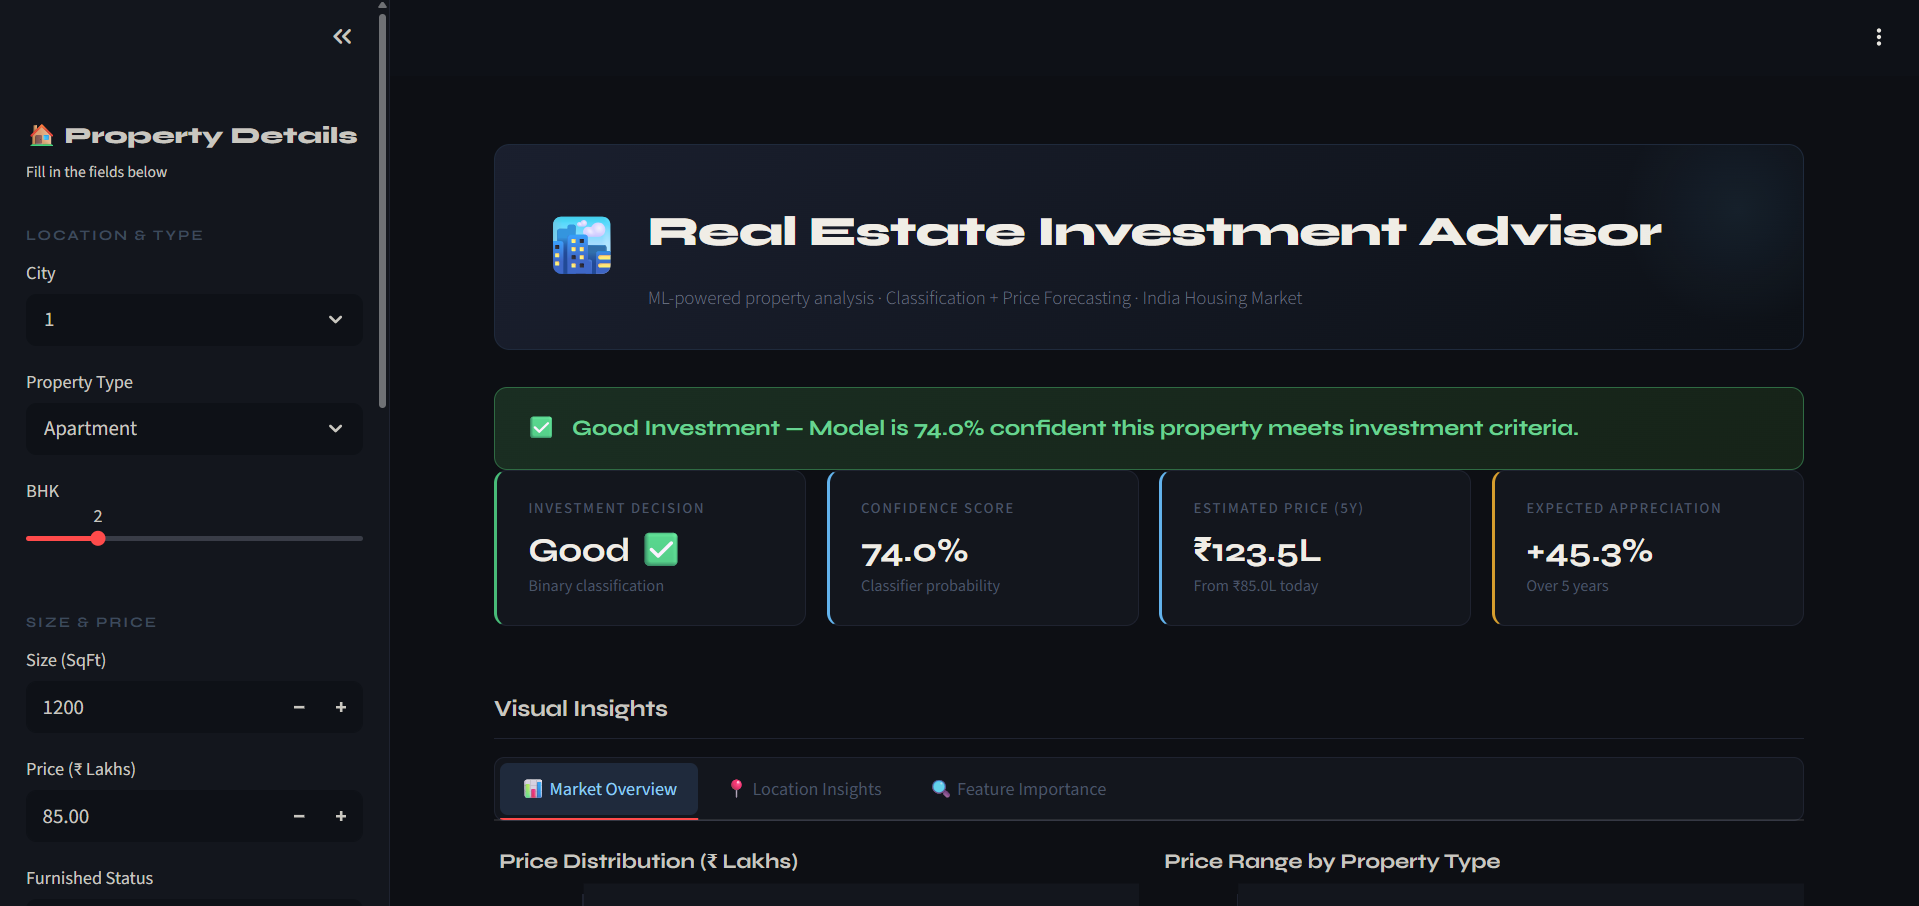

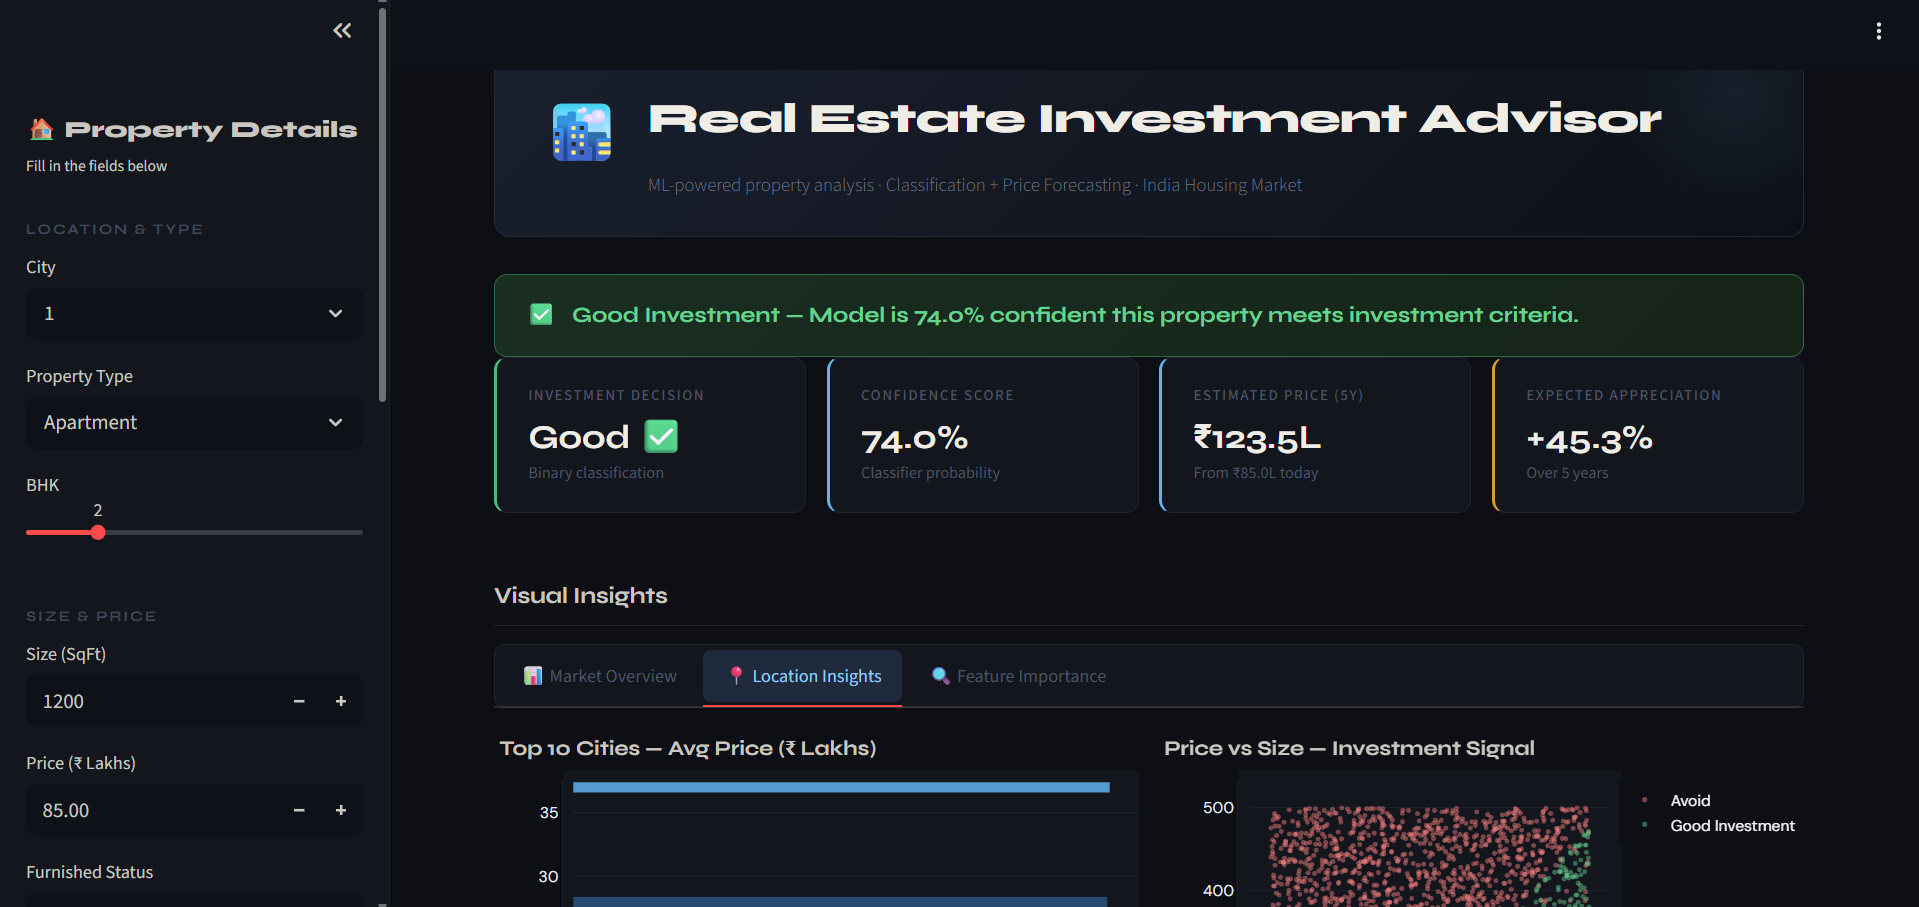

## **ThankYou**